# Bank Marketing Campaign — Predicting Term Deposit Subscription

### Machine Learning Classification Project

**Objective:** Predict whether a bank customer will subscribe to a term deposit based on customer characteristics and previous marketing campaign information.

**Dataset:** UCI Bank Marketing Dataset

**Final Model:** Gradient Boosting Classifier

**Final Classification Threshold:** 0.17

In [416]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityamhaske/bank-marketing-dataset/bank.csv
/kaggle/input/datasets/adityamhaske/bank-marketing-dataset/bank-full.csv


In [417]:
import matplotlib.pyplot as plt
import seaborn as sns

In [418]:
df = pd.read_csv(
    "/kaggle/input/datasets/adityamhaske/bank-marketing-dataset/bank-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [419]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [420]:
df.shape

(45211, 17)

In [421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [422]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [423]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [424]:
df["y"].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [425]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [426]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [427]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [428]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [429]:
df.duplicated().sum()

np.int64(0)

In [430]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [431]:
df["y"].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

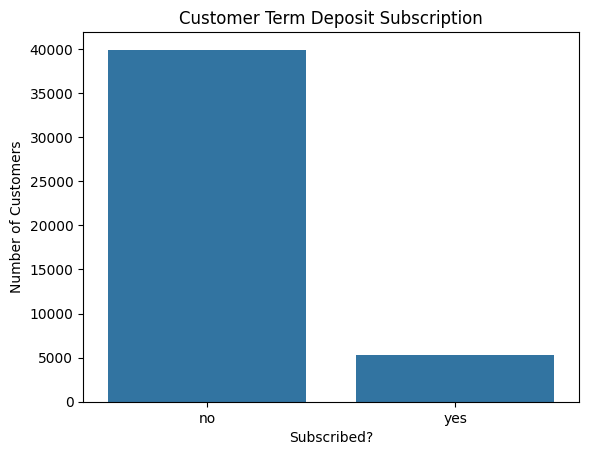

In [432]:
sns.countplot(data=df,x="y")
plt.title("Customer Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Number of Customers")

plt.show()

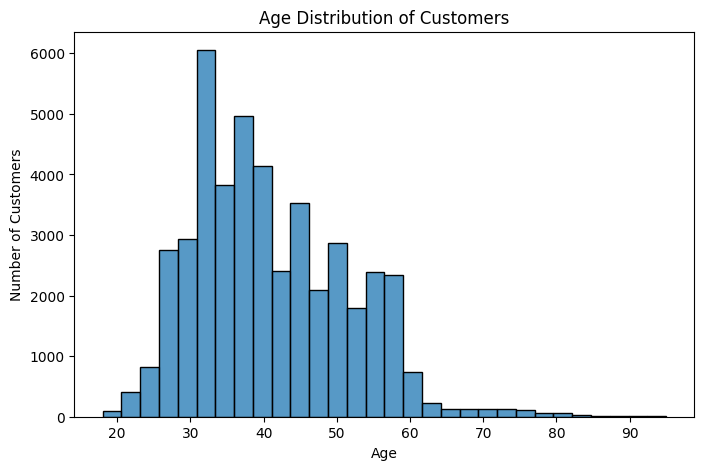

In [433]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="age",
    bins=30
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [434]:
df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

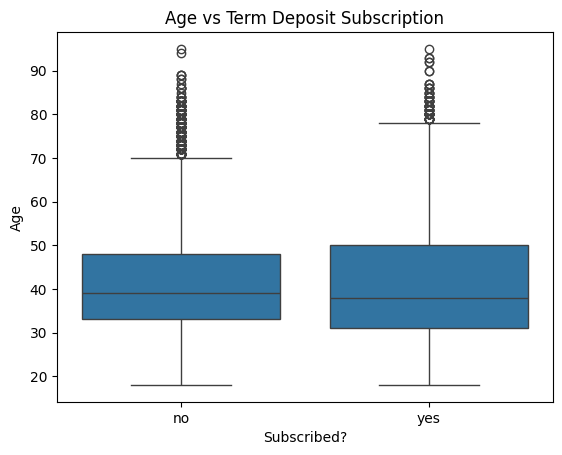

In [435]:
sns.boxplot(
    data=df,
    x="y",
    y="age"
)

plt.title("Age vs Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Age")

plt.show()

In [436]:
age_subscription = pd.crosstab(
    df["age"],
    df["y"],
    normalize="index"
) * 100

age_subscription.head(10)

y,no,yes
age,,
18,41.666667,58.333333
19,68.571429,31.428571
20,70.000000,30.000000
21,72.151899,27.848101
22,68.992248,31.007752
23,78.217822,21.782178
24,77.483444,22.516556
25,78.557875,21.442125
26,83.354037,16.645963


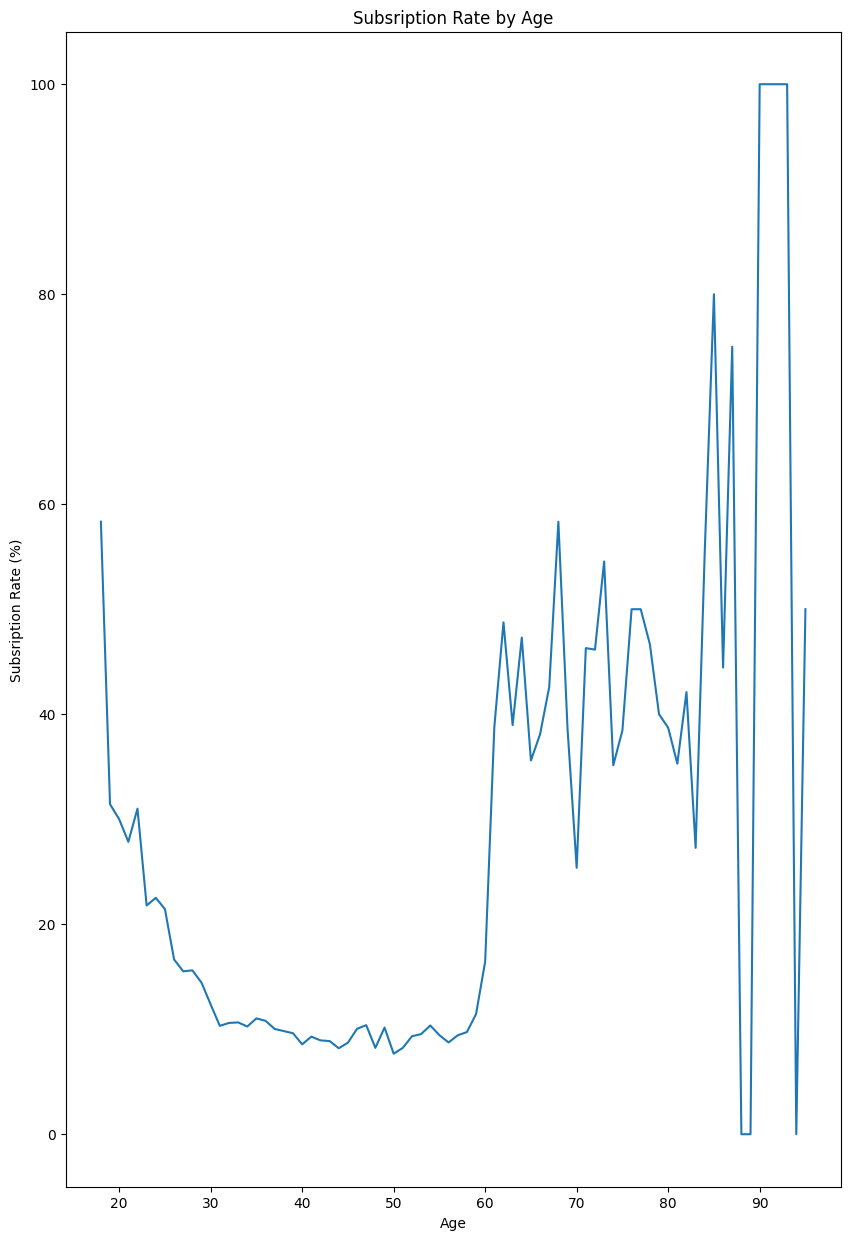

In [437]:
age_yes_rate=(
    df.groupby("age")["y"].apply(lambda x: (x=="yes").mean()*100)
)

plt.figure(figsize=(10,15))
plt.plot(
    age_yes_rate.index,
    age_yes_rate.values
)

plt.title("Subsription Rate by Age")
plt.xlabel("Age")
plt.ylabel("Subsription Rate (%)")

plt.show()

In [438]:
df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

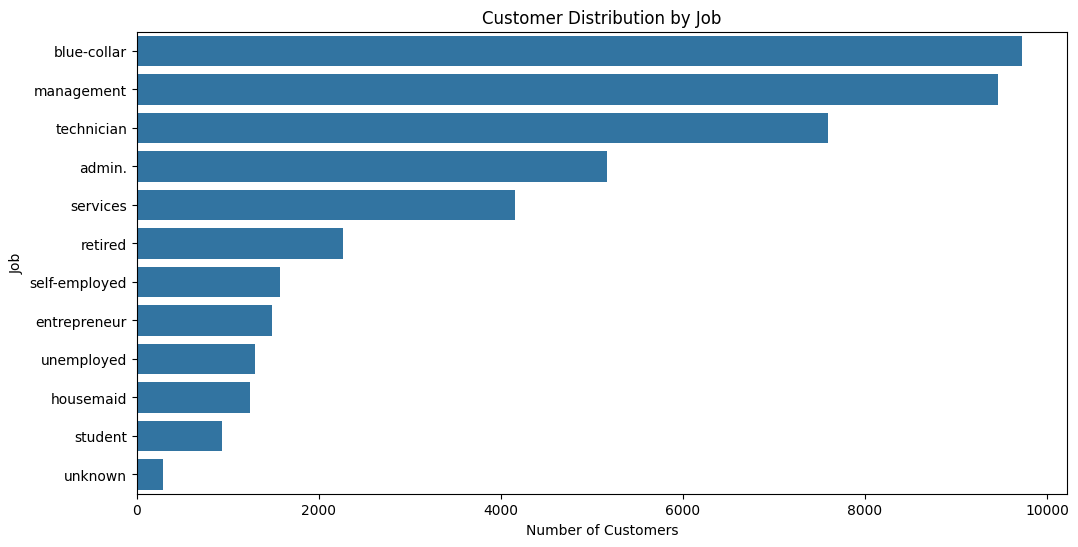

In [439]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()

In [440]:
job_subscription = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(job_subscription)

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64


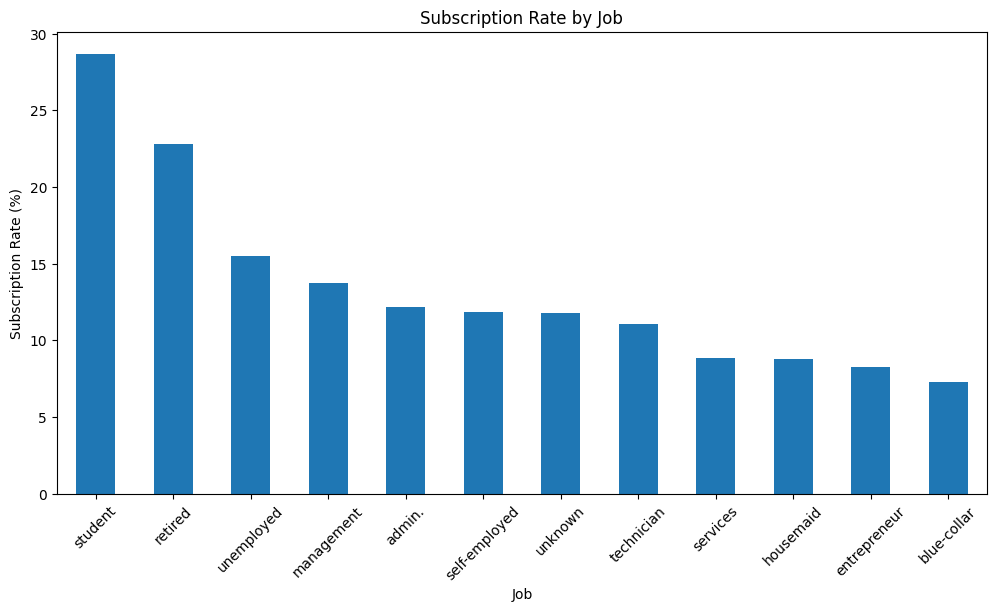

In [441]:
plt.figure(figsize=(12,6))

job_subscription.plot(kind="bar")

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [442]:
df["marital"].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [443]:
marital_subscription = (
    df.groupby("marital")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(marital_subscription)

marital
single      14.949179
divorced    11.945458
married     10.123466
Name: y, dtype: float64


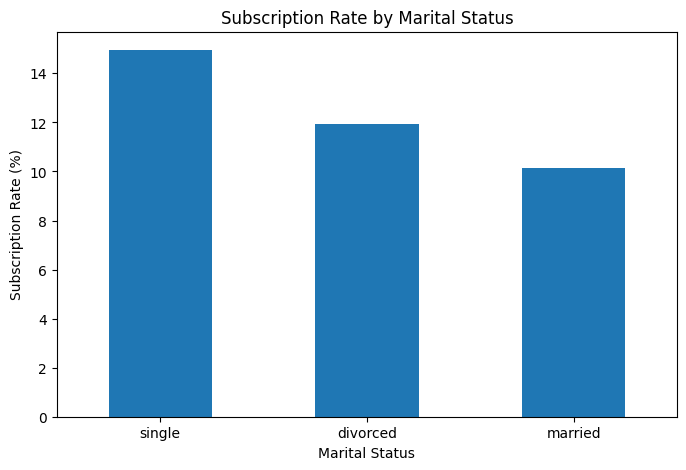

In [444]:
plt.figure(figsize=(8, 5))

marital_subscription.plot(kind="bar")

plt.title("Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [445]:
df["education"].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [446]:
education_subscription = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(education_subscription)

education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: y, dtype: float64


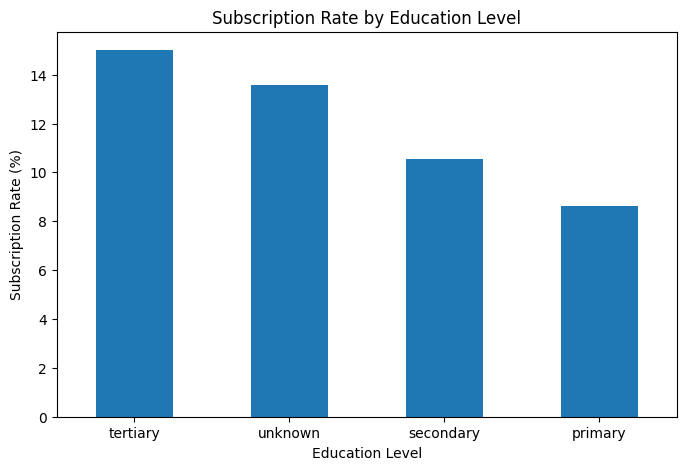

In [447]:
plt.figure(figsize=(8, 5))

education_subscription.plot(kind="bar")

plt.title("Subscription Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [448]:
df["default"].value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

In [449]:
default_subscription = (
    df.groupby("default")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(default_subscription)

default
no     11.796108
yes     6.380368
Name: y, dtype: float64


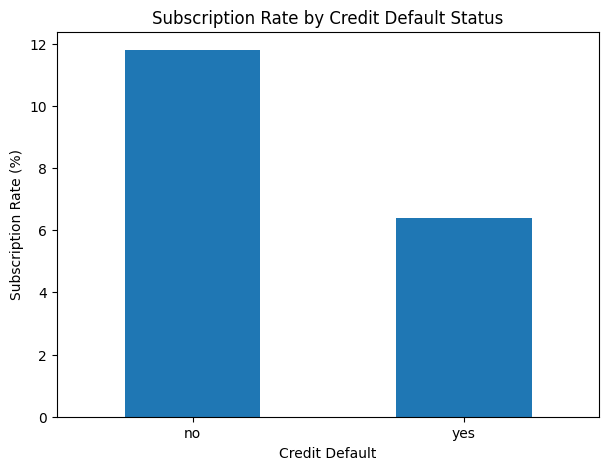

In [450]:
plt.figure(figsize=(7, 5))

default_subscription.plot(kind="bar")

plt.title("Subscription Rate by Credit Default Status")
plt.xlabel("Credit Default")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [451]:
df["housing"].value_counts()

housing
yes    25130
no     20081
Name: count, dtype: int64

In [452]:
housing_subscription = (
    df.groupby("housing")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(housing_subscription)

housing
no     16.702355
yes     7.699960
Name: y, dtype: float64


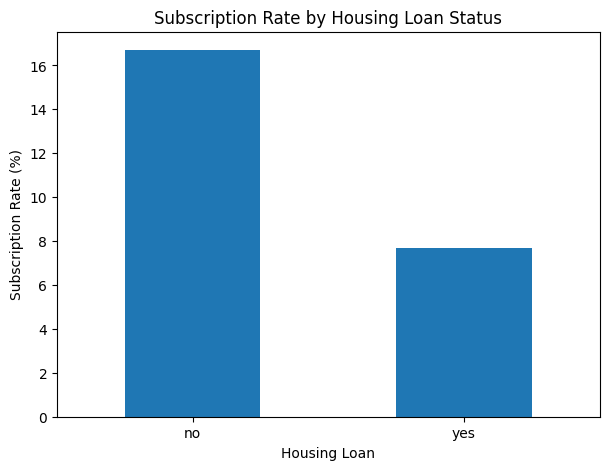

In [453]:
plt.figure(figsize=(7, 5))

housing_subscription.plot(kind="bar")

plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [454]:
df["loan"].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

In [455]:
loan_subscription = (
    df.groupby("loan")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(loan_subscription)

loan
no     12.655727
yes     6.681391
Name: y, dtype: float64


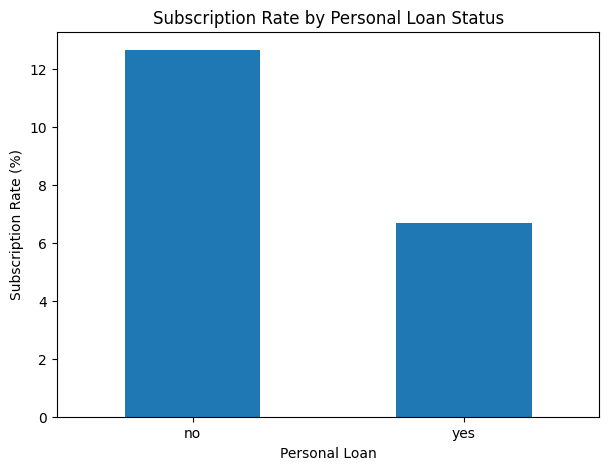

In [456]:
plt.figure(figsize=(7, 5))

loan_subscription.plot(kind="bar")

plt.title("Subscription Rate by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [457]:
df["contact"].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [458]:
contact_subscription = (
    df.groupby("contact")["y"].apply(lambda x: (x=="yes").mean()*100).sort_values(ascending=False)
)

print(contact_subscription)

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: y, dtype: float64


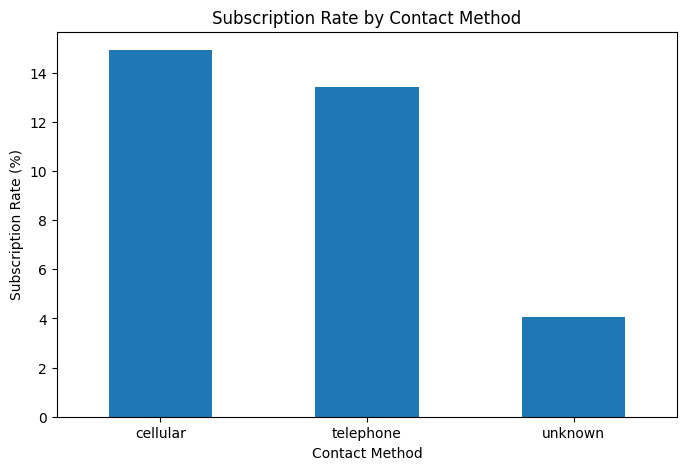

In [459]:
plt.figure(figsize=(8, 5))

contact_subscription.plot(kind="bar")

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [460]:
df["month"].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

In [461]:
month_subscription = (
    df.groupby("month")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print(month_subscription)

month
apr    19.679400
aug    11.013286
dec    46.728972
feb    16.647792
jan    10.121169
jul     9.093546
jun    10.222805
mar    51.991614
may     6.719454
nov    10.151134
oct    43.766938
sep    46.459413
Name: y, dtype: float64


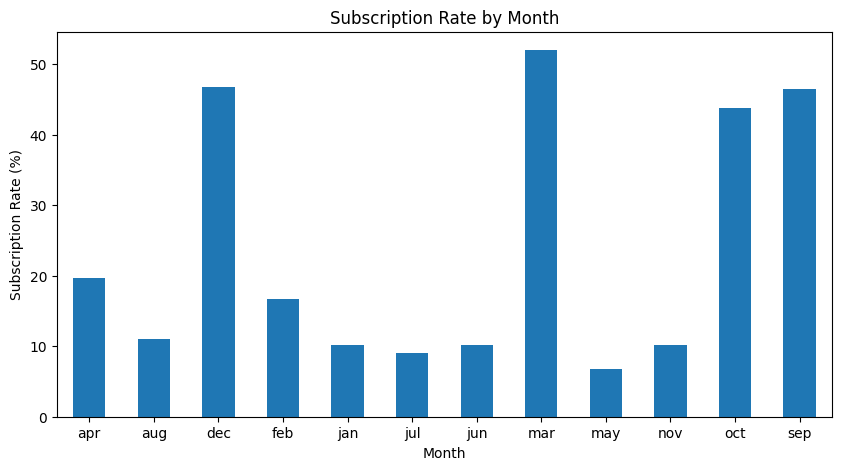

In [462]:
plt.figure(figsize=(10, 5))

month_subscription.plot(kind="bar")

plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [463]:
day_subscription = (
    df.groupby("day")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print(day_subscription)

day
1     27.950311
2     14.075793
3     16.496756
4     15.916955
5     11.256545
6      9.368530
7      8.640616
8     10.912052
9     11.467008
10    23.091603
11    12.237999
12    15.221460
13    15.205047
14    11.363636
15    13.975338
16    13.568905
17     9.076844
18     9.878683
19     6.943654
20     6.976744
21     9.921027
22    17.016575
23    13.418530
24    13.870246
25    15.833333
26    11.207729
27    13.380910
28     7.814208
29     7.392550
30    17.305236
31     7.153966
Name: y, dtype: float64


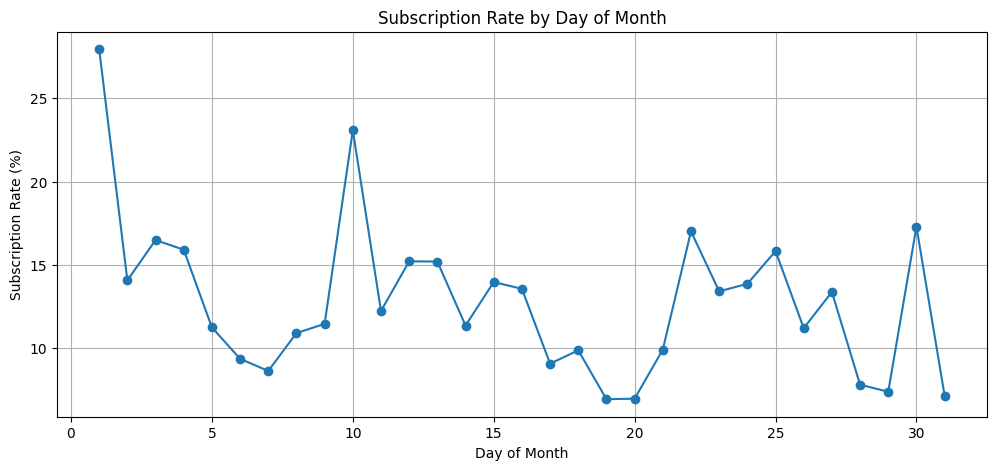

In [464]:
plt.figure(figsize=(12, 5))

plt.plot(
    day_subscription.index,
    day_subscription.values,
    marker="o"
)

plt.title("Subscription Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Subscription Rate (%)")
plt.grid(True)

plt.show()

In [465]:
df["campaign"].describe()

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

In [466]:
df["campaign"].value_counts().head(15)

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
Name: count, dtype: int64

In [467]:
campaign_subscription = (
    df.groupby("campaign")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print(campaign_subscription.head(15))

campaign
1     14.597583
2     11.203519
3     11.193624
4      9.000568
5      7.879819
6      7.126259
7      6.394558
8      5.925926
9      6.422018
10     5.263158
11     7.960199
12     2.580645
13     4.511278
14     4.301075
15     4.761905
Name: y, dtype: float64


In [468]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [469]:
poutcome_subscription = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(poutcome_subscription)

poutcome
success    64.725347
other      16.684783
failure    12.609671
unknown     9.161503
Name: y, dtype: float64


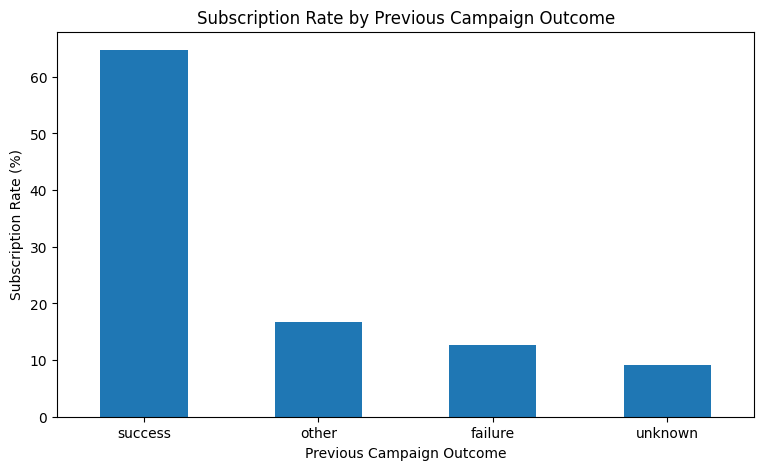

In [470]:
plt.figure(figsize=(9, 5))

poutcome_subscription.plot(kind="bar")

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [471]:
df["previous"].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

In [472]:
previous_subscription = (
    df.groupby("previous")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
)

print(previous_subscription.head(15))

previous
0      9.157331
1     21.031746
2     21.652422
3     25.744308
4     23.949580
5     26.361656
6     29.963899
7     26.341463
8     30.232558
9     26.086957
10    38.805970
11    23.076923
12    22.727273
13    23.684211
14    26.315789
Name: y, dtype: float64


In [473]:
df["balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

In [474]:
(df["balance"] < 0).sum()

np.int64(3766)

In [475]:
df["balance"].nlargest(10)

39989    102127
26227     98417
42558     81204
43393     81204
41693     71188
19785     66721
21192     66653
19420     64343
41374     59649
12926     58932
Name: balance, dtype: int64

In [476]:
balance_subscription=(df.groupby("y")["balance"].agg(["mean","median","min","max"]))
print(balance_subscription)

            mean  median   min     max
y                                     
no   1303.714969   417.0 -8019  102127
yes  1804.267915   733.0 -3058   81204


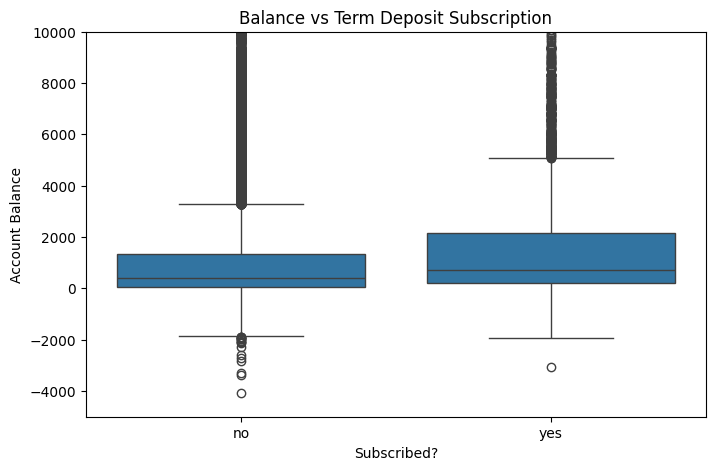

In [477]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="y", y="balance")

plt.title("Balance vs Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Account Balance")
plt.ylim(-5000, 10000)
plt.show()

In [478]:
df["balance"].corr(df["y"]=="yes").astype(int)

np.int64(0)

In [479]:
df["duration"].describe()

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

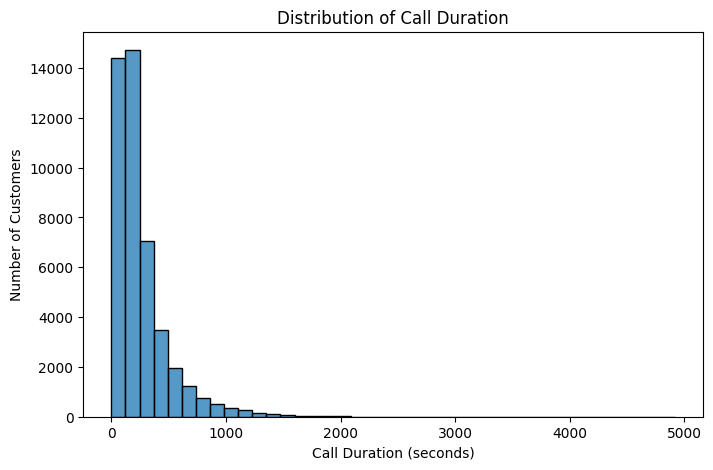

In [480]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="duration",
    bins=40
)

plt.title("Distribution of Call Duration")
plt.xlabel("Call Duration (seconds)")
plt.ylabel("Number of Customers")

plt.show()

In [481]:
duration_subscription = (
    df.groupby("y")["duration"]
    .agg(["mean", "median", "min", "max"])
)

print(duration_subscription)

           mean  median  min   max
y                                 
no   221.182806   164.0    0  4918
yes  537.294574   426.0    8  3881


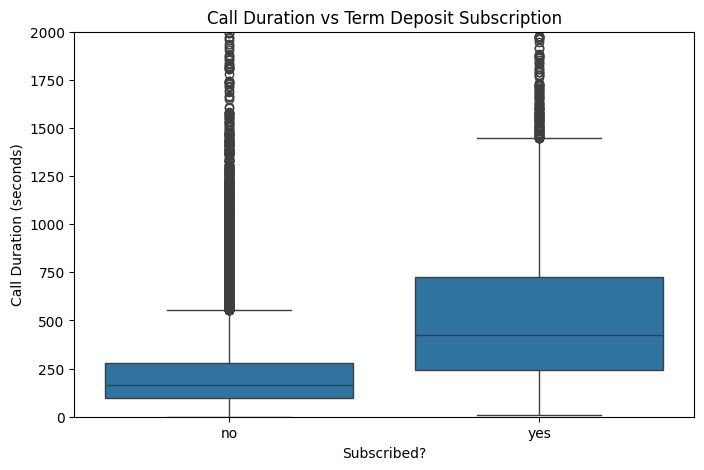

In [482]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

plt.title("Call Duration vs Term Deposit Subscription")
plt.xlabel("Subscribed?")
plt.ylabel("Call Duration (seconds)")
plt.ylim(0, 2000)

plt.show()

In [483]:
df_prep = df.copy()

In [484]:
df_prep.shape

(45211, 17)

In [485]:
df_prep.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [486]:
df_prep.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [487]:
(df_prep == 'unknown').sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

In [488]:
df_prep.duplicated().sum()

np.int64(0)

In [489]:
for col in ['job','education','contact','poutcome']:
    print(f"\n---{col}---")
    print(
        pd.crosstab(
            df_prep[col],
            df_prep['y'],
            normalize='index'
        ).round(3)
    )


---job---
y                 no    yes
job                        
admin.         0.878  0.122
blue-collar    0.927  0.073
entrepreneur   0.917  0.083
housemaid      0.912  0.088
management     0.862  0.138
retired        0.772  0.228
self-employed  0.882  0.118
services       0.911  0.089
student        0.713  0.287
technician     0.889  0.111
unemployed     0.845  0.155
unknown        0.882  0.118

---education---
y             no    yes
education              
primary    0.914  0.086
secondary  0.894  0.106
tertiary   0.850  0.150
unknown    0.864  0.136

---contact---
y             no    yes
contact                
cellular   0.851  0.149
telephone  0.866  0.134
unknown    0.959  0.041

---poutcome---
y            no    yes
poutcome              
failure   0.874  0.126
other     0.833  0.167
success   0.353  0.647
unknown   0.908  0.092


In [490]:
df_prep.nunique().sort_values()

housing         2
loan            2
default         2
y               2
contact         3
marital         3
poutcome        4
education       4
month          12
job            12
day            31
previous       41
campaign       48
age            77
pdays         559
duration     1573
balance      7168
dtype: int64

In [491]:
num_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

df_prep[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [492]:
df_prep[num_cols].skew().sort_values(ascending=False)

previous    41.846454
balance      8.360308
campaign     4.898650
duration     3.144318
pdays        2.615715
age          0.684818
day          0.093079
dtype: float64

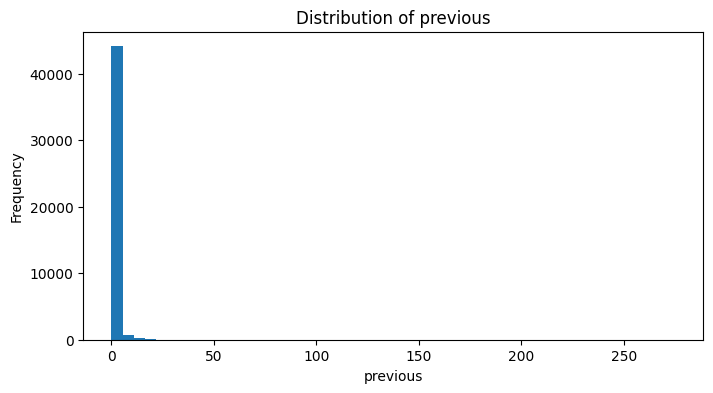

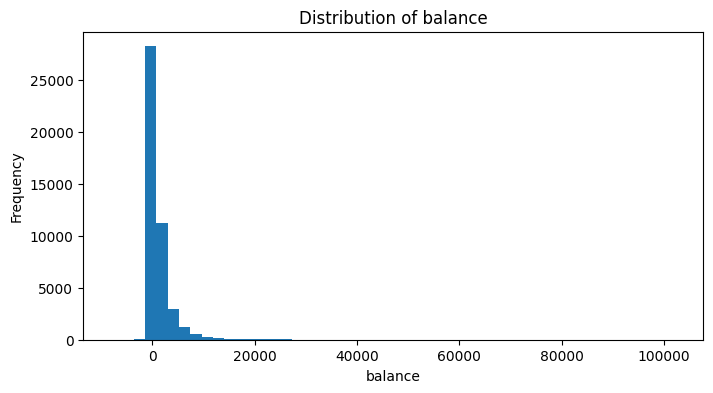

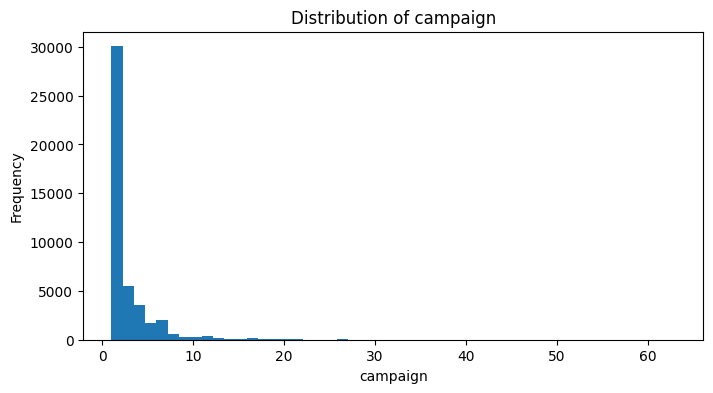

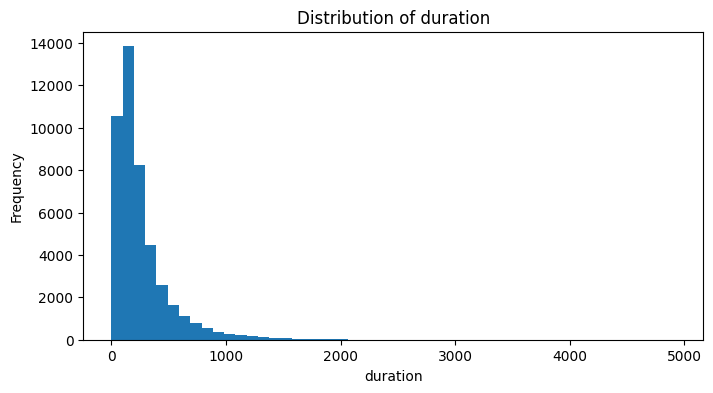

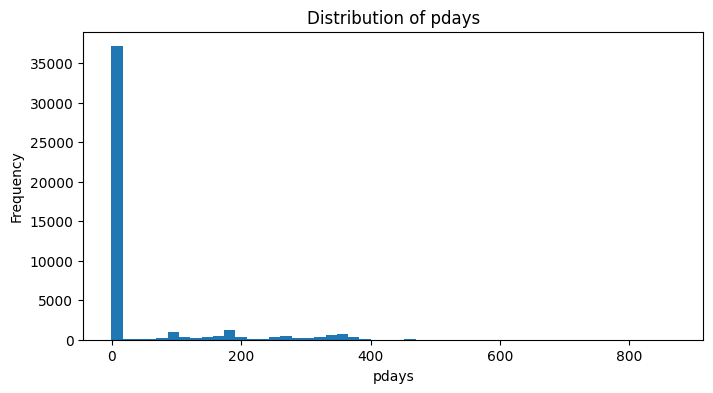

In [493]:
import matplotlib.pyplot as plt

for col in ['previous', 'balance', 'campaign', 'duration', 'pdays']:
    plt.figure(figsize=(8, 4))
    plt.hist(df_prep[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [494]:
df_prep['previously_contacted'] = (df_prep['pdays'] != -1).astype(int)

df_prep['previously_contacted'].value_counts()

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [495]:
pd.crosstab(
    df_prep['previously_contacted'],
    df_prep['y'],
    normalize='index'
).round(3)

y,no,yes
previously_contacted,,
0,0.908,0.092
1,0.769,0.231


In [496]:
df_prep['previous'].value_counts().head(15)

previous
0     36954
1      2772
2      2106
3      1142
4       714
5       459
6       277
7       205
8       129
9        92
10       67
11       65
12       44
13       38
15       20
Name: count, dtype: int64

In [497]:
df_prep['previous'].value_counts(normalize=True).head(15).round(3)

previous
0     0.817
1     0.061
2     0.047
3     0.025
4     0.016
5     0.010
6     0.006
7     0.005
8     0.003
9     0.002
10    0.001
11    0.001
12    0.001
13    0.001
15    0.000
Name: proportion, dtype: float64

In [498]:
import numpy as np

df_prep['previous_log'] = np.log1p(df_prep['previous'])

df_prep[['previous', 'previous_log']].head(10)

,previous,previous_log
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
5,0,0.0
6,0,0.0
7,0,0.0
8,0,0.0
9,0,0.0


In [499]:
df_prep[['previous', 'previous_log']].describe().T

,count,mean,std,min,25%,50%,75%,max
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.000000
previous_log,45211.0,0.226365,0.533111,0.0,0.0,0.0,0.0,5.620401


In [500]:
(df_prep['balance'] < 0).sum()

np.int64(3766)

In [501]:
(df_prep['balance'] < 0).mean()

np.float64(0.08329831235761209)

In [502]:
df_prep['negative_balance'] = (df_prep['balance'] < 0).astype(int)

df_prep['negative_balance'].value_counts()

negative_balance
0    41445
1     3766
Name: count, dtype: int64

In [503]:
pd.crosstab(
    df_prep['negative_balance'],
    df_prep['y'],
    normalize='index'
).round(3)

y,no,yes
negative_balance,,
0,0.877,0.123
1,0.944,0.056


In [504]:
df_prep['balance'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     3574.00
0.950     5768.00
0.990    13164.90
0.995    18014.35
0.999    32892.77
Name: balance, dtype: float64

In [505]:
df_prep['balance_signed_log'] = (
    np.sign(df_prep['balance']) *
    np.log1p(np.abs(df_prep['balance']))
)

In [506]:
df_prep[['balance', 'balance_signed_log']].skew()

balance               8.360308
balance_signed_log   -1.583461
dtype: float64

In [507]:
df_prep['campaign'].value_counts().sort_index().head(15)

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
Name: count, dtype: int64

In [508]:
df_prep['campaign'].value_counts(normalize=True).sort_index().head(15).round(3)

campaign
1     0.388
2     0.277
3     0.122
4     0.078
5     0.039
6     0.029
7     0.016
8     0.012
9     0.007
10    0.006
11    0.004
12    0.003
13    0.003
14    0.002
15    0.002
Name: proportion, dtype: float64

In [509]:
df_prep['campaign_log'] = np.log1p(df_prep['campaign'])

df_prep[['campaign', 'campaign_log']].head(10)

,campaign,campaign_log
0,1,0.693147
1,1,0.693147
2,1,0.693147
3,1,0.693147
4,1,0.693147
5,1,0.693147
6,1,0.693147
7,1,0.693147
8,1,0.693147
9,1,0.693147


In [510]:
df_prep[['campaign', 'campaign_log']].skew()

campaign        4.898650
campaign_log    1.326222
dtype: float64

In [511]:
df_prep[['campaign', 'campaign_log']].describe().T

,count,mean,std,min,25%,50%,75%,max
campaign,45211.0,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
campaign_log,45211.0,1.158564,0.511758,0.693147,0.693147,1.098612,1.386294,4.158883


In [512]:
pd.crosstab(
    df_prep['month'],
    df_prep['y'],
    normalize='index'
).round(3)

y,no,yes
month,,
apr,0.803,0.197
aug,0.890,0.110
dec,0.533,0.467
feb,0.834,0.166
jan,0.899,0.101
jul,0.909,0.091
jun,0.898,0.102
mar,0.480,0.520
may,0.933,0.067


In [513]:
pd.crosstab(
    df_prep['day'],
    df_prep['y'],
    normalize='index'
).round(3)

y,no,yes
day,,
1,0.720,0.280
2,0.859,0.141
3,0.835,0.165
4,0.841,0.159
5,0.887,0.113
6,0.906,0.094
7,0.914,0.086
8,0.891,0.109
9,0.885,0.115


In [514]:
df_prep['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [515]:
df_prep['y'].value_counts(normalize=True).round(3)

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

In [516]:
leakage_cols = ['duration']

df_prep[leakage_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,45211.0,258.16308,257.527812,0.0,103.0,180.0,319.0,4918.0


In [517]:
X = df_prep.drop(columns=['y', 'duration'])
y = df_prep['y']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 20)
y shape: (45211,)


In [518]:
X.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'previously_contacted',
 'previous_log',
 'negative_balance',
 'balance_signed_log',
 'campaign_log']

In [519]:
X.dtypes

age                       int64
job                      object
marital                  object
education                object
default                  object
balance                   int64
housing                  object
loan                     object
contact                  object
day                       int64
month                    object
campaign                  int64
pdays                     int64
previous                  int64
poutcome                 object
previously_contacted      int64
previous_log            float64
negative_balance          int64
balance_signed_log      float64
campaign_log            float64
dtype: object

In [520]:
numeric_features = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous',
    'previous_log',
    'balance_signed_log',
    'campaign_log'
]

categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

binary_features = [
    'previously_contacted',
    'negative_balance'
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Binary:", len(binary_features))
print("Total:", len(numeric_features) + len(categorical_features) + len(binary_features))

Numeric: 9
Categorical: 9
Binary: 2
Total: 20


In [521]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 20)
X_test: (9043, 20)
y_train: (36168,)
y_test: (9043,)


In [522]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Test target distribution:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


In [523]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numeric_features),
        ('cat',categorical_transformer, categorical_features),
        ('bin','passthrough',binary_features)
    ]
)

In [524]:
from sklearn.linear_model import LogisticRegression
logistic_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous', 'previous_log',
                                                   'balance_signed_log',
                                                   'campaign_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['previously_contacted',
                                                   'negative_balance'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [525]:
logistic_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous', 'previous_log',
                                                   'balance_signed_log',
                                                   'campaign_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['previously_contacted',
                                                   'negative_balance'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [526]:
y_pred=logistic_model.predict(X_test)
y_pred[:20]

array(['no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'no'],
      dtype=object)

In [527]:
y_prob=logistic_model.predict_proba(X_test)[:,1]
y_prob[:10]

array([0.01459109, 0.02687326, 0.03511704, 0.01801168, 0.15182392,
       0.07086711, 0.07556766, 0.82932958, 0.11848342, 0.09904377])

In [528]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[7888,   97],
       [ 875,  183]])

In [529]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.65      0.17      0.27      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



In [530]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_model=DummyClassifier(
    strategy='most_frequent'
)

dummy_model.fit(X_train,y_train)
dummy_pred=dummy_model.predict(X_test)
print("Dummy accuracy:", accuracy_score(y_test,dummy_pred))

Dummy accuracy: 0.8830034280659074


In [531]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test,y_prob)
print("ROC-AUC:",round(roc_auc,4))

ROC-AUC: 0.7734


In [533]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (28934, 20)
Validation: (7234, 20)
Test: (9043, 20)


In [534]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous', 'previous_log',
                                                   'balance_signed_log',
                                                   'campaign_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['previously_contacted',
                                                   'negative_balance'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [535]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

print(y_val_prob[:10])

[0.17577356 0.16050618 0.70932849 0.01482161 0.03046129 0.19759273
 0.37435493 0.0957356  0.14655587 0.01777604]


In [536]:
from sklearn.metrics import precision_score,recall_score,f1_score

thresholds=[0.10,0.20,0.30,0.40,0.50]

for threshold in thresholds:
    y_val_pred=(y_val_prob>=threshold).astype(int)
    precision=precision_score(
        (y_val=='yes').astype(int),
        y_val_pred
    )
    recall=recall_score(
        (y_val=='yes').astype(int),
        y_val_pred
    )
    f1=f1_score(
        (y_val=='yes').astype(int),
        y_val_pred
    )
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.222 | Recall: 0.716 | F1: 0.339
Threshold: 0.20 | Precision: 0.447 | Recall: 0.450 | F1: 0.448
Threshold: 0.30 | Precision: 0.549 | Recall: 0.333 | F1: 0.415
Threshold: 0.40 | Precision: 0.618 | Recall: 0.245 | F1: 0.351
Threshold: 0.50 | Precision: 0.689 | Recall: 0.181 | F1: 0.287


In [537]:
import numpy as np
from sklearn.metrics import precision_recall_curve

y_val_binary = (y_val == 'yes').astype(int)

precision, recall, thresholds = precision_recall_curve(
    y_val_binary,
    y_val_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", round(best_threshold, 4))
print("Best F1:", round(best_f1, 4))
print("Precision:", round(precision[best_idx], 4))
print("Recall:", round(recall[best_idx], 4))

Best threshold: 0.1942
Best F1: 0.4519
Precision: 0.4409
Recall: 0.4634


In [538]:
y_test_prob = logistic_model.predict_proba(X_test)[:, 1]

y_test_binary = (y_test == 'yes').astype(int)

y_test_pred_tuned = (y_test_prob >= best_threshold).astype(int)

print("Test predictions:", y_test_pred_tuned[:10])

Test predictions: [0 0 0 0 0 0 0 1 0 0]


In [539]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Precision:", round(
    precision_score(y_test_binary, y_test_pred_tuned), 4
))

print("Recall:", round(
    recall_score(y_test_binary, y_test_pred_tuned), 4
))

print("F1:", round(
    f1_score(y_test_binary, y_test_pred_tuned), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_test_pred_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test_binary,
        y_test_pred_tuned,
        target_names=['no', 'yes']
    )
)

Precision: 0.446
Recall: 0.4565
F1: 0.4512

Confusion Matrix:
[[7385  600]
 [ 575  483]]

Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.92      0.93      7985
         yes       0.45      0.46      0.45      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.69      0.69      9043
weighted avg       0.87      0.87      0.87      9043



In [540]:
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 55
['num__age' 'num__balance' 'num__day' 'num__campaign' 'num__pdays'
 'num__previous' 'num__previous_log' 'num__balance_signed_log'
 'num__campaign_log' 'cat__job_admin.' 'cat__job_blue-collar'
 'cat__job_entrepreneur' 'cat__job_housemaid' 'cat__job_management'
 'cat__job_retired' 'cat__job_self-employed' 'cat__job_services'
 'cat__job_student' 'cat__job_technician' 'cat__job_unemployed']


In [541]:
coefficients = logistic_model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df.sort_values(
    'abs_coefficient',
    ascending=False
).head(15)

,feature,coefficient,abs_coefficient
51,cat__poutcome_success,1.353852,1.353852
41,cat__month_jan,-1.133901,1.133901
44,cat__month_mar,1.066154,1.066154
36,cat__contact_unknown,-0.966761,0.966761
49,cat__poutcome_failure,-0.825762,0.825762
46,cat__month_nov,-0.810208,0.810208
39,cat__month_dec,0.694623,0.694623
38,cat__month_aug,-0.689685,0.689685
48,cat__month_sep,0.665008,0.665008
47,cat__month_oct,0.637913,0.637913


In [542]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

coef_df.sort_values(
    'abs_coefficient',
    ascending=False
).head(15)

,feature,coefficient,abs_coefficient,odds_ratio
51,cat__poutcome_success,1.353852,1.353852,3.872311
41,cat__month_jan,-1.133901,1.133901,0.321776
44,cat__month_mar,1.066154,1.066154,2.904189
36,cat__contact_unknown,-0.966761,0.966761,0.380313
49,cat__poutcome_failure,-0.825762,0.825762,0.437901
46,cat__month_nov,-0.810208,0.810208,0.444766
39,cat__month_dec,0.694623,0.694623,2.002954
38,cat__month_aug,-0.689685,0.689685,0.501734
48,cat__month_sep,0.665008,0.665008,1.944506
47,cat__month_oct,0.637913,0.637913,1.892527


In [543]:
coef_df['direction'] = np.where(
    coef_df['coefficient'] > 0,
    'Positive',
    'Negative'
)

top_positive = coef_df.sort_values(
    'coefficient',
    ascending=False
).head(10)

top_negative = coef_df.sort_values(
    'coefficient',
    ascending=True
).head(10)

print("TOP POSITIVE FEATURES")
display(top_positive[['feature', 'coefficient', 'odds_ratio']])

print("\nTOP NEGATIVE FEATURES")
display(top_negative[['feature', 'coefficient', 'odds_ratio']])

TOP POSITIVE FEATURES


,feature,coefficient,odds_ratio
51,cat__poutcome_success,1.353852,3.872311
44,cat__month_mar,1.066154,2.904189
39,cat__month_dec,0.694623,2.002954
48,cat__month_sep,0.665008,1.944506
47,cat__month_oct,0.637913,1.892527
54,bin__negative_balance,0.551684,1.736174
14,cat__job_retired,0.379119,1.460996
34,cat__contact_cellular,0.324395,1.383194
17,cat__job_student,0.308209,1.360985
7,num__balance_signed_log,0.278514,1.321165



TOP NEGATIVE FEATURES


,feature,coefficient,odds_ratio
41,cat__month_jan,-1.133901,0.321776
36,cat__contact_unknown,-0.966761,0.380313
49,cat__poutcome_failure,-0.825762,0.437901
46,cat__month_nov,-0.810208,0.444766
38,cat__month_aug,-0.689685,0.501734
42,cat__month_jul,-0.597915,0.549957
50,cat__poutcome_other,-0.579137,0.560382
31,cat__housing_yes,-0.505446,0.603237
52,cat__poutcome_unknown,-0.443385,0.641860
12,cat__job_housemaid,-0.423826,0.654537


In [544]:
coef_df['original_feature'] = (
    coef_df['feature']
    .str.replace(r'^(num__|cat__|bin__)', '', regex=True)
    .str.rsplit('_', n=1)
    .str[0]
)

feature_importance = (
    coef_df.groupby('original_feature')['abs_coefficient']
    .mean()
    .sort_values(ascending=False)
)

print(feature_importance)

original_feature
poutcome          0.800534
month             0.609934
negative          0.551684
contact           0.479697
balance_signed    0.278514
housing           0.258230
default           0.247216
loan              0.247216
marital           0.164810
job               0.164418
campaign          0.124448
education         0.123641
previous          0.089339
day               0.036678
previously        0.025244
pdays             0.019659
balance           0.017592
age               0.005167
Name: abs_coefficient, dtype: float64


In [545]:
coef_df['original_feature'] = (
    coef_df['feature']
    .str.replace(r'^(num__|cat__|bin__)', '', regex=True)
)

for feature in numeric_features + categorical_features + binary_features:
    mask = coef_df['original_feature'].str.startswith(feature + '_')
    coef_df.loc[mask, 'original_feature'] = feature

feature_importance = (
    coef_df.groupby('original_feature')['abs_coefficient']
    .mean()
    .sort_values(ascending=False)
)

print(feature_importance)

original_feature
poutcome                0.800534
month                   0.609934
negative_balance        0.551684
contact                 0.479697
housing                 0.258230
default                 0.247216
loan                    0.247216
marital                 0.164810
job                     0.164418
balance                 0.148053
campaign                0.124448
education               0.123641
previous                0.089339
day                     0.036678
previously_contacted    0.025244
pdays                   0.019659
age                     0.005167
Name: abs_coefficient, dtype: float64


In [546]:
from sklearn.inspection import permutation_importance

perm_result=permutation_importance(
    logistic_model,
    X_val,
    y_val_binary,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

In [547]:
perm_df=pd.DataFrame({
    'feature':X_val.columns,
    'importance_mean':perm_result.importances_mean,
    'importance_std':perm_result.importances_std
})
perm_df=perm_df.sort_values(
    'importance_mean',
    ascending=False
)
perm_df.head(20)

,feature,importance_mean,importance_std
8,contact,0.065187,0.004998
10,month,0.038641,0.003058
14,poutcome,0.028312,0.002693
18,balance_signed_log,0.020520,0.003068
6,housing,0.014982,0.002519
2,marital,0.005790,0.001694
16,previous_log,0.005040,0.001716
7,loan,0.004101,0.001188
1,job,0.003172,0.000838
19,campaign_log,0.002017,0.000912


In [548]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [549]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous', 'previous_log',
                                                   'balance_signed_log',
                                                   'campaign_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['previously_contacted',
                                                   'negative_balance'])])),
                ('classifier', KNeighborsClassifier())])

In [550]:
y_knn_pred = knn_model.predict(X_test)
y_knn_prob = knn_model.predict_proba(X_test)[:, 1]

In [551]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

y_test_binary = (y_test == 'yes').astype(int)

print("KNN Accuracy:", round(accuracy_score(y_test, y_knn_pred), 4))
print("KNN Precision:", round(precision_score(y_test, y_knn_pred, pos_label='yes'), 4))
print("KNN Recall:", round(recall_score(y_test, y_knn_pred, pos_label='yes'), 4))
print("KNN F1:", round(f1_score(y_test, y_knn_pred, pos_label='yes'), 4))
print("KNN ROC-AUC:", round(roc_auc_score(y_test_binary, y_knn_prob), 4))
print("KNN PR-AUC:", round(average_precision_score(y_test_binary, y_knn_prob), 4))

KNN Accuracy: 0.8852
KNN Precision: 0.5246
KNN Recall: 0.2013
KNN F1: 0.291
KNN ROC-AUC: 0.6929
KNN PR-AUC: 0.2801


In [552]:
from sklearn.naive_bayes import GaussianNB

nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

In [553]:
nb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous', 'previous_log',
                                                   'balance_signed_log',
                                                   'campaign_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('bin', 'passthrough',
                                                  ['previously_contacted',
                                                   'negative_balance'])])),
                ('classifier', GaussianNB())])

In [554]:
y_nb_pred = nb_model.predict(X_test)
y_nb_prob = nb_model.predict_proba(X_test)[:, 1]

print("Naive Bayes Accuracy:", round(accuracy_score(y_test, y_nb_pred), 4))
print("Naive Bayes Precision:", round(precision_score(y_test, y_nb_pred, pos_label='yes'), 4))
print("Naive Bayes Recall:", round(recall_score(y_test, y_nb_pred, pos_label='yes'), 4))
print("Naive Bayes F1:", round(f1_score(y_test, y_nb_pred, pos_label='yes'), 4))
print("Naive Bayes ROC-AUC:", round(roc_auc_score(y_test_binary, y_nb_prob), 4))
print("Naive Bayes PR-AUC:", round(average_precision_score(y_test_binary, y_nb_prob), 4))

Naive Bayes Accuracy: 0.8225
Naive Bayes Precision: 0.3283
Naive Bayes Recall: 0.4943
Naive Bayes F1: 0.3946
Naive Bayes ROC-AUC: 0.7474
Naive Bayes PR-AUC: 0.3503


In [555]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    ))
])

In [556]:
dt_model.fit(X_train, y_train)

y_dt_pred = dt_model.predict(X_test)
y_dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [557]:
print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_dt_pred), 4))
print("Decision Tree Precision:", round(precision_score(y_test, y_dt_pred, pos_label='yes'), 4))
print("Decision Tree Recall:", round(recall_score(y_test, y_dt_pred, pos_label='yes'), 4))
print("Decision Tree F1:", round(f1_score(y_test, y_dt_pred, pos_label='yes'), 4))
print("Decision Tree ROC-AUC:", round(roc_auc_score(y_test_binary, y_dt_prob), 4))
print("Decision Tree PR-AUC:", round(average_precision_score(y_test_binary, y_dt_prob), 4))

Decision Tree Accuracy: 0.8938
Decision Tree Precision: 0.6678
Decision Tree Recall: 0.1843
Decision Tree F1: 0.2889
Decision Tree ROC-AUC: 0.7123
Decision Tree PR-AUC: 0.3161


In [558]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [559]:
rf_model.fit(X_train, y_train)

y_rf_pred = rf_model.predict(X_test)
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [560]:
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_rf_pred), 4))
print("Random Forest Precision:", round(precision_score(y_test, y_rf_pred, pos_label='yes'), 4))
print("Random Forest Recall:", round(recall_score(y_test, y_rf_pred, pos_label='yes'), 4))
print("Random Forest F1:", round(f1_score(y_test, y_rf_pred, pos_label='yes'), 4))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test_binary, y_rf_prob), 4))
print("Random Forest PR-AUC:", round(average_precision_score(y_test_binary, y_rf_prob), 4))

Random Forest Accuracy: 0.8067
Random Forest Precision: 0.3268
Random Forest Recall: 0.6153
Random Forest F1: 0.4269
Random Forest ROC-AUC: 0.7929
Random Forest PR-AUC: 0.4321


In [561]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=10,
        random_state=42
    ))
])

In [562]:
gb_model.fit(X_train, y_train)

y_gb_pred = gb_model.predict(X_test)
y_gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [563]:
print("Gradient Boosting Accuracy:", round(accuracy_score(y_test, y_gb_pred), 4))
print("Gradient Boosting Precision:", round(precision_score(y_test, y_gb_pred, pos_label='yes'), 4))
print("Gradient Boosting Recall:", round(recall_score(y_test, y_gb_pred, pos_label='yes'), 4))
print("Gradient Boosting F1:", round(f1_score(y_test, y_gb_pred, pos_label='yes'), 4))
print("Gradient Boosting ROC-AUC:", round(roc_auc_score(y_test_binary, y_gb_prob), 4))
print("Gradient Boosting PR-AUC:", round(average_precision_score(y_test_binary, y_gb_prob), 4))

Gradient Boosting Accuracy: 0.8941
Gradient Boosting Precision: 0.6656
Gradient Boosting Recall: 0.19
Gradient Boosting F1: 0.2956
Gradient Boosting ROC-AUC: 0.7978
Gradient Boosting PR-AUC: 0.4488


In [564]:
# Use the already-trained Gradient Boosting model
y_gb_val_prob = gb_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.51, 0.01)

results = []

for threshold in thresholds:
    pred = (y_gb_val_prob >= threshold).astype(int)

    results.append({
        'threshold': threshold,
        'precision': precision_score(y_val_binary, pred),
        'recall': recall_score(y_val_binary, pred),
        'f1': f1_score(y_val_binary, pred)
    })

threshold_df = pd.DataFrame(results)

best_threshold = threshold_df.loc[
    threshold_df['f1'].idxmax(), 'threshold'
]

print("Best threshold:", round(best_threshold, 2))
print(
    threshold_df.loc[
        threshold_df['f1'].idxmax()
    ]
)

Best threshold: 0.19
threshold    0.190000
precision    0.479781
recall       0.518913
f1           0.498580
Name: 14, dtype: float64


In [565]:
y_gb_test_prob = gb_model.predict_proba(X_test)[:, 1]

y_gb_test_tuned = (
    y_gb_test_prob >= best_threshold
).astype(int)

print("Gradient Boosting Tuned Accuracy:",
      round(accuracy_score(y_test_binary, y_gb_test_tuned), 4))

print("Gradient Boosting Tuned Precision:",
      round(precision_score(y_test_binary, y_gb_test_tuned), 4))

print("Gradient Boosting Tuned Recall:",
      round(recall_score(y_test_binary, y_gb_test_tuned), 4))

print("Gradient Boosting Tuned F1:",
      round(f1_score(y_test_binary, y_gb_test_tuned), 4))

print("Gradient Boosting ROC-AUC:",
      round(roc_auc_score(y_test_binary, y_gb_test_prob), 4))

print("Gradient Boosting PR-AUC:",
      round(average_precision_score(y_test_binary, y_gb_test_prob), 4))

Gradient Boosting Tuned Accuracy: 0.8796
Gradient Boosting Tuned Precision: 0.4855
Gradient Boosting Tuned Recall: 0.4905
Gradient Boosting Tuned F1: 0.488
Gradient Boosting ROC-AUC: 0.7978
Gradient Boosting PR-AUC: 0.4488


In [566]:
# Get transformed feature names
feature_names = gb_model.named_steps['preprocessor'].get_feature_names_out()

# Get Gradient Boosting importance
importances = gb_model.named_steps['classifier'].feature_importances_

gb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

gb_importance = gb_importance.sort_values(
    'importance', ascending=False
)

gb_importance.head(15)

,feature,importance
51,cat__poutcome_success,0.413383
0,num__age,0.074151
2,num__day,0.052372
44,cat__month_mar,0.050470
36,cat__contact_unknown,0.049440
43,cat__month_jun,0.045529
4,num__pdays,0.043438
37,cat__month_apr,0.041479
47,cat__month_oct,0.037424
31,cat__housing_yes,0.024901


[[7435  550]
 [ 539  519]]


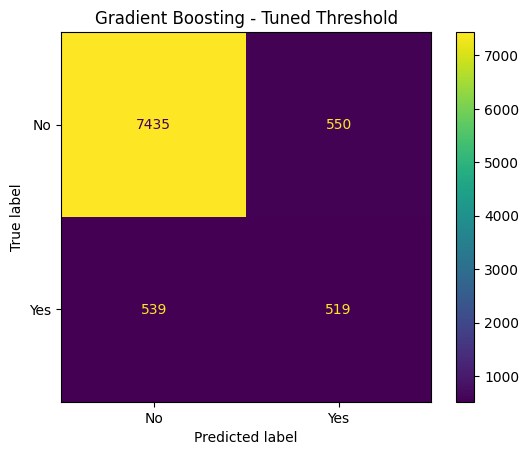

In [567]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_binary, y_gb_test_tuned)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
).plot()

plt.title("Gradient Boosting - Tuned Threshold")
plt.show()

In [568]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'F1': [
        0.4489,
        0.2787,
        0.3954,
        0.3182,
        0.4184,
        0.4828
    ],
    'ROC_AUC': [
        0.7734,
        0.6890,
        0.7466,
        0.7176,
        0.7880,
        0.7983
    ],
    'PR_AUC': [
        0.4137,
        0.2706,
        0.3495,
        0.3234,
        0.4226,
        0.4427
    ]
})

final_results.sort_values('F1', ascending=False)

,Model,F1,ROC_AUC,PR_AUC
5,Gradient Boosting,0.4828,0.7983,0.4427
0,Logistic Regression,0.4489,0.7734,0.4137
4,Random Forest,0.4184,0.7880,0.4226
2,Naive Bayes,0.3954,0.7466,0.3495
3,Decision Tree,0.3182,0.7176,0.3234
1,KNN,0.2787,0.6890,0.2706


In [569]:
import joblib

joblib.dump(gb_model, 'bank_marketing_gradient_boosting.pkl')

joblib.dump(
    {'model': gb_model, 'threshold': 0.17},
    'bank_marketing_final_model.pkl'
)

print("Final model saved successfully.")

Final model saved successfully.


## Business Insights

The model provides several useful insights for bank marketing campaigns:

### 1. Previous campaign outcome is highly informative
Customers who previously responded positively to a campaign are substantially more likely to subscribe again.

### 2. Contact method matters
The type of contact used by the bank has a strong relationship with subscription behavior. This suggests that communication strategy can influence campaign effectiveness.

### 3. Campaign timing matters
Different months show substantially different subscription rates, indicating that campaign timing can affect customer response.

### 4. Customer characteristics matter
Variables such as age, housing status, balance, and previous campaign history contribute to the model's predictions.

### 5. Targeting is preferable to contacting everyone
Because only 11.7% of customers in the dataset subscribed, contacting every customer equally can result in substantial inefficient outreach. The model can instead be used to prioritize customers with higher predicted probabilities.

## Limitations

- The dataset contains a significant class imbalance.
- The model was evaluated on historical campaign data and may not generalize perfectly to future campaigns.
- `duration` was excluded because it is known during/after a call and could cause data leakage in a pre-call prediction system.
- The probability threshold of 0.17 was selected to improve the balance between precision and recall, but the optimal threshold would depend on the bank's actual business costs.
- Further improvement could come from hyperparameter tuning, probability calibration, external validation, and monitoring after deployment.

## Conclusion

This project developed an end-to-end machine learning pipeline for predicting whether bank customers would subscribe to a term deposit.

Six classification algorithms were evaluated. Gradient Boosting achieved the strongest overall performance, with a ROC-AUC of 0.7983 and PR-AUC of 0.4427.

After optimizing the classification threshold using the validation set, the final model achieved an F1-score of 0.4828 and recall of 0.5028 on the previously unseen test set.

The resulting model can be used as a customer prioritization tool, helping marketing teams focus their efforts on customers who are more likely to respond positively to a campaign.

Overall, the project demonstrates the complete machine learning workflow from exploratory data analysis and feature engineering through model comparison, threshold optimization, evaluation, and business interpretation.